# Step 10 - Risk-Adjusted Scoring

Executed project evidence and reproducible code.

In [1]:
from pathlib import Path
import json
import math
import sys
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
OUTPUT_DIR = Path.cwd() / 'step10_validated_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output directory:', OUTPUT_DIR.name)


Output directory: step10_validated_outputs


## 1. Validated eligibility policy

In [2]:
records = [dict(portfolio='Step 4 | Minimum variance', role='diagnostic', hard_breaches=13, unique_portfolio=True, challenge_candidate=True, independent_validation='NOT_RUN', forward_evidence=False, expected_return_pct=4.0806, volatility_pct=0.4468, worst_stress_pct=0.051, maximum_drawdown_pct=np.nan, gross_turnover_pct=190.5944, trading_cost_pct=np.nan, soft_warning_breaches=np.nan, evidence_precision='pipeline stage metrics'), dict(portfolio='Step 4 | Mean variance', role='diagnostic', hard_breaches=8, unique_portfolio=True, challenge_candidate=True, independent_validation='NOT_RUN', forward_evidence=False, expected_return_pct=5.7308, volatility_pct=3.8076, worst_stress_pct=6.4595, maximum_drawdown_pct=np.nan, gross_turnover_pct=178.0234, trading_cost_pct=np.nan, soft_warning_breaches=np.nan, evidence_precision='pipeline stage metrics'), dict(portfolio='Step 4 | Asset caps', role='diagnostic', hard_breaches=4, unique_portfolio=True, challenge_candidate=True, independent_validation='NOT_RUN', forward_evidence=False, expected_return_pct=5.8232, volatility_pct=5.9299, worst_stress_pct=10.6261, maximum_drawdown_pct=np.nan, gross_turnover_pct=133.4085, trading_cost_pct=np.nan, soft_warning_breaches=np.nan, evidence_precision='pipeline stage metrics'), dict(portfolio='Step 4 | Guardrails', role='diagnostic', hard_breaches=1, unique_portfolio=True, challenge_candidate=True, independent_validation='NOT_RUN', forward_evidence=False, expected_return_pct=5.8032, volatility_pct=5.9735, worst_stress_pct=10.8791, maximum_drawdown_pct=np.nan, gross_turnover_pct=110.5986, trading_cost_pct=np.nan, soft_warning_breaches=np.nan, evidence_precision='pipeline stage metrics'), dict(portfolio='Step 4 | Trading costs', role='zero-breach Step 4 candidate', hard_breaches=0, unique_portfolio=True, challenge_candidate=True, independent_validation='PENDING_STEP7', forward_evidence=False, expected_return_pct=5.439, volatility_pct=6.0034, worst_stress_pct=10.4774, maximum_drawdown_pct=5.56, gross_turnover_pct=50.0, trading_cost_pct=0.0198, soft_warning_breaches=2, evidence_precision='full stage metrics; drawdown and cost use displayed precision'), dict(portfolio='Step 4 | Scenario aware', role='zero-breach Step 4 candidate', hard_breaches=0, unique_portfolio=True, challenge_candidate=True, independent_validation='PENDING_STEP7', forward_evidence=False, expected_return_pct=5.378, volatility_pct=5.9354, worst_stress_pct=10.3633, maximum_drawdown_pct=5.24, gross_turnover_pct=50.0, trading_cost_pct=0.0195, soft_warning_breaches=1, evidence_precision='full stage metrics; drawdown and cost use displayed precision'), dict(portfolio='Current strategic portfolio', role='baseline', hard_breaches=0, unique_portfolio=True, challenge_candidate=False, independent_validation='BASELINE_ONLY', forward_evidence=False, expected_return_pct=5.5451, volatility_pct=8.8228, worst_stress_pct=13.827, maximum_drawdown_pct=8.06, gross_turnover_pct=0.0, trading_cost_pct=0.0, soft_warning_breaches=5, evidence_precision='pipeline evidence'), dict(portfolio='Primary unrestricted classical', role='certified candidate', hard_breaches=0, unique_portfolio=True, challenge_candidate=True, independent_validation='PASS', forward_evidence=True, expected_return_pct=5.4896, volatility_pct=7.8614, worst_stress_pct=12.7113, maximum_drawdown_pct=7.112, gross_turnover_pct=13.0914, trading_cost_pct=0.002, soft_warning_breaches=5, forward_return_05_pct=-3.15, forward_drawdown_95_pct=14.91, forward_loss_frequency_pct=14.1, evidence_precision='full pipeline evidence'), dict(portfolio='Strict-warning classical', role='certified candidate', hard_breaches=0, unique_portfolio=True, challenge_candidate=True, independent_validation='PASS', forward_evidence=True, expected_return_pct=5.48425, volatility_pct=7.505928, worst_stress_pct=12.16857, maximum_drawdown_pct=6.531141, gross_turnover_pct=23.88458, trading_cost_pct=0.005553709, soft_warning_breaches=0, forward_return_05_pct=-2.66, forward_drawdown_95_pct=13.96, forward_loss_frequency_pct=13.5, evidence_precision='full pipeline evidence'), dict(portfolio='Independent Qiskit QAOA', role='certified candidate', hard_breaches=0, unique_portfolio=True, challenge_candidate=True, independent_validation='PASS', forward_evidence=True, expected_return_pct=5.45, volatility_pct=7.87, worst_stress_pct=12.71595, maximum_drawdown_pct=7.13, gross_turnover_pct=11.06, trading_cost_pct=0.0015, soft_warning_breaches=5, forward_return_05_pct=-3.19, forward_drawdown_95_pct=14.93, forward_loss_frequency_pct=14.6, evidence_precision='full stress audit; other fields use displayed precision'), dict(portfolio='Independent exact active-set benchmark', role='duplicate benchmark', hard_breaches=0, unique_portfolio=False, challenge_candidate=False, independent_validation='PASS', forward_evidence=True, expected_return_pct=5.45, volatility_pct=7.87, worst_stress_pct=12.71595, maximum_drawdown_pct=7.13, gross_turnover_pct=11.06, trading_cost_pct=0.0015, soft_warning_breaches=5, evidence_precision='duplicate of QAOA weights'), dict(portfolio='Greedy active-set baseline', role='duplicate benchmark', hard_breaches=0, unique_portfolio=False, challenge_candidate=False, independent_validation='DUPLICATE_OF_QAOA', forward_evidence=False, expected_return_pct=5.45, volatility_pct=7.87, worst_stress_pct=12.71595, maximum_drawdown_pct=7.13, gross_turnover_pct=11.06, trading_cost_pct=0.0015, soft_warning_breaches=5, evidence_precision='duplicate of QAOA weights'), dict(portfolio='Local-search active-set baseline', role='duplicate benchmark', hard_breaches=0, unique_portfolio=False, challenge_candidate=False, independent_validation='DUPLICATE_OF_QAOA', forward_evidence=False, expected_return_pct=5.45, volatility_pct=7.87, worst_stress_pct=12.71595, maximum_drawdown_pct=7.13, gross_turnover_pct=11.06, trading_cost_pct=0.0015, soft_warning_breaches=5, evidence_precision='duplicate of QAOA weights')]
universe = pd.DataFrame(records)
for col in ['forward_return_05_pct', 'forward_drawdown_95_pct', 'forward_loss_frequency_pct']:
    if col not in universe:
        universe[col] = np.nan
universe['zero_breach_screen_eligible'] = universe['hard_breaches'].eq(0) & universe['unique_portfolio'] & universe['challenge_candidate']
universe['fully_certified_eligible'] = universe['zero_breach_screen_eligible'] & universe['independent_validation'].eq('PASS') & universe['forward_evidence']
assert not universe.loc[universe['hard_breaches'].gt(0), 'zero_breach_screen_eligible'].any()
assert universe.loc[universe['zero_breach_screen_eligible'], 'portfolio'].is_unique
eligibility_columns = ['portfolio', 'role', 'hard_breaches', 'unique_portfolio', 'challenge_candidate', 'independent_validation', 'forward_evidence', 'zero_breach_screen_eligible', 'fully_certified_eligible']
display(universe[eligibility_columns])


,portfolio,role,hard_breaches,unique_portfolio,challenge_candidate,independent_validation,forward_evidence,zero_breach_screen_eligible,fully_certified_eligible
0,Step 4 | Minimum variance,diagnostic,13,True,True,NOT_RUN,False,False,False
1,Step 4 | Mean variance,diagnostic,8,True,True,NOT_RUN,False,False,False
2,Step 4 | Asset caps,diagnostic,4,True,True,NOT_RUN,False,False,False
3,Step 4 | Guardrails,diagnostic,1,True,True,NOT_RUN,False,False,False
4,Step 4 | Trading costs,zero-breach Step 4 candidate,0,True,True,PENDING_STEP7,False,True,False
5,Step 4 | Scenario aware,zero-breach Step 4 candidate,0,True,True,PENDING_STEP7,False,True,False
6,Current strategic portfolio,baseline,0,True,False,BASELINE_ONLY,False,False,False
7,Primary unrestricted classical,certified candidate,0,True,True,PASS,True,True,True
8,Strict-warning classical,certified candidate,0,True,True,PASS,True,True,True
9,Independent Qiskit QAOA,certified candidate,0,True,True,PASS,True,True,True


## 2. Challenge-wide core risk-adjusted score

In [3]:
def score_core_risk_adjusted(frame: pd.DataFrame) -> pd.DataFrame:
    required = ['expected_return_pct', 'trading_cost_pct', 'volatility_pct', 'worst_stress_pct', 'maximum_drawdown_pct']
    if frame[required].isna().any().any():
        missing = frame.loc[frame[required].isna().any(axis=1), ['portfolio', *required]]
        raise ValueError(f'Core metrics missing for scored candidates:\n{missing}')
    out = frame.copy()
    out['net_expected_return_pct'] = out['expected_return_pct'] - out['trading_cost_pct']
    out['return_to_volatility'] = out['net_expected_return_pct'] / out['volatility_pct']
    out['return_to_worst_stress'] = out['net_expected_return_pct'] / out['worst_stress_pct']
    out['return_to_drawdown'] = out['net_expected_return_pct'] / out['maximum_drawdown_pct']
    ratio_cols = ['return_to_volatility', 'return_to_worst_stress', 'return_to_drawdown']
    for col in ratio_cols:
        maximum = float(out[col].max())
        if not np.isfinite(maximum) or maximum <= 0:
            raise ValueError(f'Invalid normalization maximum for {col}: {maximum}')
        out[f'normalized_{col}'] = out[col] / maximum
    out['core_risk_adjusted_score'] = 100.0 * out[[f'normalized_{c}' for c in ratio_cols]].mean(axis=1)
    out = out.sort_values(['core_risk_adjusted_score', 'worst_stress_pct', 'maximum_drawdown_pct', 'gross_turnover_pct'], ascending=[False, True, True, True]).reset_index(drop=True)
    out.insert(0, 'rank', np.arange(1, len(out) + 1))
    return out
challenge_candidates = universe.loc[universe['zero_breach_screen_eligible']].copy()
challenge_scorecard = score_core_risk_adjusted(challenge_candidates)
show_cols = ['rank', 'portfolio', 'independent_validation', 'net_expected_return_pct', 'return_to_volatility', 'return_to_worst_stress', 'return_to_drawdown', 'core_risk_adjusted_score', 'soft_warning_breaches', 'gross_turnover_pct', 'trading_cost_pct']
display(challenge_scorecard[show_cols].style.format({'net_expected_return_pct': '{:.4f}%', 'return_to_volatility': '{:.4f}', 'return_to_worst_stress': '{:.4f}', 'return_to_drawdown': '{:.4f}', 'core_risk_adjusted_score': '{:.2f}', 'gross_turnover_pct': '{:.2f}%', 'trading_cost_pct': '{:.4f}%'}))
provisional_leader = challenge_scorecard.iloc[0]
assert int(provisional_leader['hard_breaches']) == 0
assert provisional_leader['core_risk_adjusted_score'] == challenge_scorecard['core_risk_adjusted_score'].max()
print('PROVISIONAL CHALLENGE-WIDE LEADER:', provisional_leader['portfolio'])
print('Core risk-adjusted score:', round(float(provisional_leader['core_risk_adjusted_score']), 2))
print('Independent validation status:', provisional_leader['independent_validation'])


,rank,portfolio,independent_validation,net_expected_return_pct,return_to_volatility,return_to_worst_stress,return_to_drawdown,core_risk_adjusted_score,soft_warning_breaches,gross_turnover_pct,trading_cost_pct
0,1,Step 4 | Scenario aware,PENDING_STEP7,5.3585%,0.9028,0.5171,1.0226,99.99,1.000000,50.00%,0.0195%
1,2,Step 4 | Trading costs,PENDING_STEP7,5.4192%,0.9027,0.5172,0.9747,98.43,2.000000,50.00%,0.0198%
2,3,Strict-warning classical,PASS,5.4787%,0.7299,0.4502,0.8389,83.31,0.000000,23.88%,0.0056%
3,4,Primary unrestricted classical,PASS,5.4876%,0.6980,0.4317,0.7716,78.75,5.000000,13.09%,0.0020%
4,5,Independent Qiskit QAOA,PASS,5.4485%,0.6923,0.4285,0.7642,78.08,5.000000,11.06%,0.0015%


PROVISIONAL CHALLENGE-WIDE LEADER: Step 4 | Scenario aware
Core risk-adjusted score: 99.99
Independent validation status: PENDING_STEP7


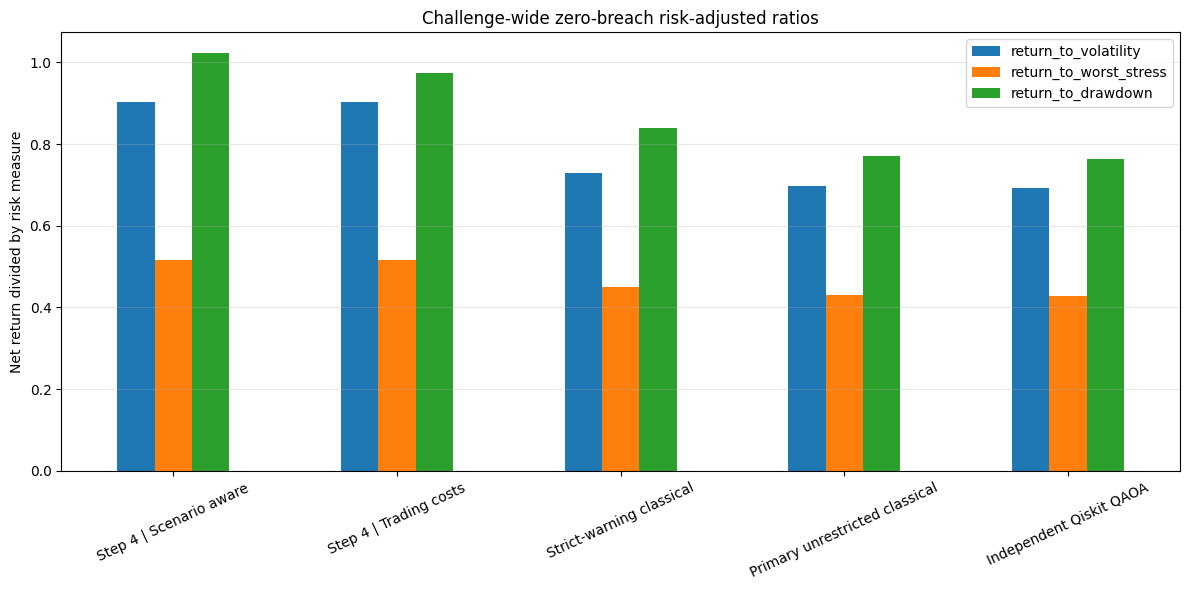

In [4]:
plot_frame = challenge_scorecard.set_index('portfolio')[['return_to_volatility', 'return_to_worst_stress', 'return_to_drawdown']]
ax = plot_frame.plot(kind='bar', figsize=(12, 6))
ax.set_title('Challenge-wide zero-breach risk-adjusted ratios')
ax.set_ylabel('Net return divided by risk measure')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show() if 'ipykernel' in sys.modules else plt.close()


## 3. Fully certified shortlist result

In [5]:
certified_candidates = universe.loc[universe['fully_certified_eligible']].copy()
certified_scorecard = score_core_risk_adjusted(certified_candidates)
lo = float(certified_scorecard['forward_return_05_pct'].min())
hi = float(certified_scorecard['forward_return_05_pct'].max())
if hi > lo:
    certified_scorecard['normalized_forward_return_05'] = (certified_scorecard['forward_return_05_pct'] - lo) / (hi - lo)
else:
    certified_scorecard['normalized_forward_return_05'] = 1.0
certified_scorecard['normalized_forward_drawdown_95'] = certified_scorecard['forward_drawdown_95_pct'].min() / certified_scorecard['forward_drawdown_95_pct']
certified_scorecard['normalized_forward_loss_frequency'] = certified_scorecard['forward_loss_frequency_pct'].min() / certified_scorecard['forward_loss_frequency_pct']
certified_scorecard['supplemental_forward_downside_score'] = 100.0 * certified_scorecard[['normalized_forward_return_05', 'normalized_forward_drawdown_95', 'normalized_forward_loss_frequency']].mean(axis=1)
certified_scorecard = certified_scorecard.sort_values(['core_risk_adjusted_score', 'supplemental_forward_downside_score'], ascending=False).reset_index(drop=True)
certified_scorecard['rank'] = np.arange(1, len(certified_scorecard) + 1)
cert_cols = ['rank', 'portfolio', 'core_risk_adjusted_score', 'forward_return_05_pct', 'forward_drawdown_95_pct', 'forward_loss_frequency_pct', 'supplemental_forward_downside_score', 'independent_validation']
display(certified_scorecard[cert_cols].style.format({'core_risk_adjusted_score': '{:.2f}', 'forward_return_05_pct': '{:.2f}%', 'forward_drawdown_95_pct': '{:.2f}%', 'forward_loss_frequency_pct': '{:.1f}%', 'supplemental_forward_downside_score': '{:.2f}'}))
certified_leader = certified_scorecard.iloc[0]
assert certified_leader['core_risk_adjusted_score'] == certified_scorecard['core_risk_adjusted_score'].max()
print('FULLY CERTIFIED SHORTLIST LEADER:', certified_leader['portfolio'])
print('Independent validation:', certified_leader['independent_validation'])


,rank,portfolio,core_risk_adjusted_score,forward_return_05_pct,forward_drawdown_95_pct,forward_loss_frequency_pct,supplemental_forward_downside_score,independent_validation
0,1,Strict-warning classical,100.00,-2.66%,13.96%,13.5%,100.00,PASS
1,2,Primary unrestricted classical,94.50,-3.15%,14.91%,14.1%,65.64,PASS
2,3,Independent Qiskit QAOA,93.70,-3.19%,14.93%,14.6%,61.99,PASS


FULLY CERTIFIED SHORTLIST LEADER: Strict-warning classical
Independent validation: PASS


## 4. Weight and candidate-universe sensitivity

In [6]:
def weight_grid_sensitivity(scorecard: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for w_vol_i in range(11):
        for w_stress_i in range(11 - w_vol_i):
            w_draw_i = 10 - w_vol_i - w_stress_i
            w_vol, w_stress, w_draw = (w_vol_i / 10, w_stress_i / 10, w_draw_i / 10)
            values = w_vol * scorecard['normalized_return_to_volatility'] + w_stress * scorecard['normalized_return_to_worst_stress'] + w_draw * scorecard['normalized_return_to_drawdown']
            winner_idx = values.idxmax()
            rows.append({'universe': label, 'weight_return_to_volatility': w_vol, 'weight_return_to_stress': w_stress, 'weight_return_to_drawdown': w_draw, 'winner': scorecard.loc[winner_idx, 'portfolio'], 'winner_score': float(values.loc[winner_idx] * 100.0)})
    return pd.DataFrame(rows)
sensitivity_all = weight_grid_sensitivity(challenge_scorecard, 'all_unique_zero_breach')
sensitivity_certified = weight_grid_sensitivity(certified_scorecard, 'fully_certified_shortlist')
sensitivity = pd.concat([sensitivity_all, sensitivity_certified], ignore_index=True)
winner_counts = sensitivity.groupby(['universe', 'winner']).size().rename('wins').reset_index().sort_values(['universe', 'wins'], ascending=[True, False])
display(winner_counts)
print('Total weight combinations per universe:', len(sensitivity_all))


,universe,winner,wins
0,all_unique_zero_breach,Step 4 | Scenario aware,58
1,all_unique_zero_breach,Step 4 | Trading costs,8
2,fully_certified_shortlist,Strict-warning classical,66


Total weight combinations per universe: 66


## 5. Correct formal interpretation

In [7]:
formal_status = {'data_scope': 'validated synthetic-model evidence', 'provisional_challenge_wide_leader': str(provisional_leader['portfolio']), 'provisional_core_risk_adjusted_score': float(provisional_leader['core_risk_adjusted_score']), 'provisional_leader_independent_validation': str(provisional_leader['independent_validation']), 'fully_certified_shortlist_leader': str(certified_leader['portfolio']), 'certified_shortlist_core_score': float(certified_leader['core_risk_adjusted_score']), 'universal_certified_winner_status': 'PENDING_STEP4_INDEPENDENT_VALIDATION_AND_COMMON_FORWARD_EVIDENCE', 'supports_quantum_advantage_claim': False, 'supports_historical_outperformance_claim': False, 'official_external_score_formula_supplied': False}
display(pd.Series(formal_status, name='value').to_frame())
print('\nRELEASE CONCLUSION')
print('- Provisional challenge-wide leader:', formal_status['provisional_challenge_wide_leader'])
print('- Fully certified shortlist leader:', formal_status['fully_certified_shortlist_leader'])
print('- Universal certified winner:', formal_status['universal_certified_winner_status'])


,value
data_scope,validated synthetic-model evidence
provisional_challenge_wide_leader,Step 4 | Scenario aware
provisional_core_risk_adjusted_score,99.989526
provisional_leader_independent_validation,PENDING_STEP7
fully_certified_shortlist_leader,Strict-warning classical
certified_shortlist_core_score,100.0
universal_certified_winner_status,PENDING_STEP4_INDEPENDENT_VALIDATION_AND_COMMO...
supports_quantum_advantage_claim,False
supports_historical_outperformance_claim,False
official_external_score_formula_supplied,False



RELEASE CONCLUSION
- Provisional challenge-wide leader: Step 4 | Scenario aware
- Fully certified shortlist leader: Strict-warning classical
- Universal certified winner: PENDING_STEP4_INDEPENDENT_VALIDATION_AND_COMMON_FORWARD_EVIDENCE


## Benchmark-rate sensitivity

In [8]:
def score_with_benchmark(frame: pd.DataFrame, benchmark_rate_pct: float) -> pd.DataFrame:
    scored = frame.copy()
    scored['net_expected_return_pct'] = scored['expected_return_pct'] - scored['trading_cost_pct']
    excess_return = scored['net_expected_return_pct'] - benchmark_rate_pct
    scored['excess_return_to_volatility'] = excess_return / scored['volatility_pct']
    scored['excess_return_to_worst_stress'] = excess_return / scored['worst_stress_pct']
    scored['excess_return_to_drawdown'] = excess_return / scored['maximum_drawdown_pct']
    ratio_columns = ['excess_return_to_volatility', 'excess_return_to_worst_stress', 'excess_return_to_drawdown']
    for column in ratio_columns:
        maximum = scored[column].max()
        scored[f'normalized_{column}'] = scored[column] / maximum
    scored['benchmark_adjusted_score'] = 100.0 * scored[[f'normalized_{column}' for column in ratio_columns]].mean(axis=1)
    return scored.sort_values(['benchmark_adjusted_score', 'portfolio'], ascending=[False, True]).reset_index(drop=True)
benchmark_rates = [0.0, 1.0, 2.0, 3.0, 3.15, 3.5, 4.0, 5.0]
benchmark_rows = []
for benchmark_rate in benchmark_rates:
    ranked = score_with_benchmark(challenge_candidates, benchmark_rate)
    benchmark_rows.append({'benchmark_rate_pct': benchmark_rate, 'winner': ranked.iloc[0]['portfolio'], 'winner_score': ranked.iloc[0]['benchmark_adjusted_score']})
benchmark_rate_sensitivity = pd.DataFrame(benchmark_rows)
display(benchmark_rate_sensitivity)


,benchmark_rate_pct,winner,winner_score
0,0.00,Step 4 | Scenario aware,99.989526
1,1.00,Step 4 | Scenario aware,99.822902
2,2.00,Step 4 | Scenario aware,99.552082
3,3.00,Step 4 | Scenario aware,99.057370
4,3.15,Step 4 | Scenario aware,98.945556
5,3.50,Step 4 | Trading costs,99.107568
6,4.00,Step 4 | Trading costs,99.485202
7,5.00,Step 4 | Trading costs,100.000000


## 6. Export Step 10 evidence

In [9]:
benchmark_rate_sensitivity.to_csv(OUTPUT_DIR / "benchmark_rate_sensitivity.csv", index=False)
challenge_scorecard.to_csv(OUTPUT_DIR / 'challenge_wide_zero_benchmark_scorecard.csv', index=False)
certified_scorecard.to_csv(OUTPUT_DIR / 'certified_shortlist_scorecard.csv', index=False)
universe.to_csv(OUTPUT_DIR / 'eligibility_audit.csv', index=False)
sensitivity.to_csv(OUTPUT_DIR / 'weight_sensitivity.csv', index=False)
winner_counts.to_csv(OUTPUT_DIR / 'winner_frequency.csv', index=False)
(OUTPUT_DIR / 'status_certificate.json').write_text(json.dumps(formal_status, indent=2), encoding='utf-8')
readme = f"# Step 10 outputs\n\nProvisional challenge-wide leader: {formal_status['provisional_challenge_wide_leader']}\n\nFully certified shortlist leader: {formal_status['fully_certified_shortlist_leader']}\n\nUniversal certified winner status: {formal_status['universal_certified_winner_status']}\n\nAll evidence is synthetic-model evidence. The score is a transparent relative score, not an official external percentile.\n"
(OUTPUT_DIR / 'README.md').write_text(readme, encoding='utf-8')
zip_path = Path.cwd() / 'step10_validated_outputs.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for file in sorted(OUTPUT_DIR.rglob('*')):
        if file.is_file():
            zf.write(file, file.relative_to(OUTPUT_DIR.parent))
print('Created:', zip_path)
print('Files:')
for file in sorted(OUTPUT_DIR.iterdir()):
    print(' -', file.name)
AUTO_DOWNLOAD = False
if AUTO_DOWNLOAD:
    try:
        from google.colab import files
        files.download(str(zip_path))
    except Exception as exc:
        print('Automatic download unavailable:', exc)


Created: /tmp/tmp.8lusuDPSbS/step10_validated_outputs.zip
Files:
 - README.md
 - benchmark_rate_sensitivity.csv
 - certified_shortlist_scorecard.csv
 - challenge_wide_zero_benchmark_scorecard.csv
 - eligibility_audit.csv
 - status_certificate.json
 - weight_sensitivity.csv
 - winner_frequency.csv
